In [1]:
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics

In [2]:
function smooth_imgs(img, size_kernel)
    """ Smooth the images with a flat kernel to find the stripes more easily """
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    """ Normalize the images to use the same threshold for all the pictures in a dataset """
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_droplets_radius_range(img, droplet_radius_range, threshold_droplets)
    """ Finds the center of each droplets on a given picture """
    blob_centers = []
    response = zeros(size(img))

    for droplet_radius in droplet_radius_range
        log_kernel = Kernel.gaussian(droplet_radius)
        response .+= imfilter(img, log_kernel)
        response = response .* droplet_radius^2
    end

    blobs = response .> threshold_droplets # Adaptative threshold depending on the std of the img

    label_blobs = label_components(blobs) # Separate the blobs
    for label in 1:maximum(label_blobs) # Find the center of each blob
        inds = findall(label_blobs .== label)
        push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
    end

    return blob_centers, label_blobs
end

find_droplets_radius_range (generic function with 1 method)

### Load the images/ODs

In [3]:
pathdir = "Y:/TwoDGas/2026/01/19/0046"

@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Amplitude_laser τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset
nbr_amp_laser = length(unique(Amplitude_laser))

# Droplet parameters
size_kernel_smooth = 5
droplet_radius_range = [3:0.2:4;];

### Find the droplet thresholds

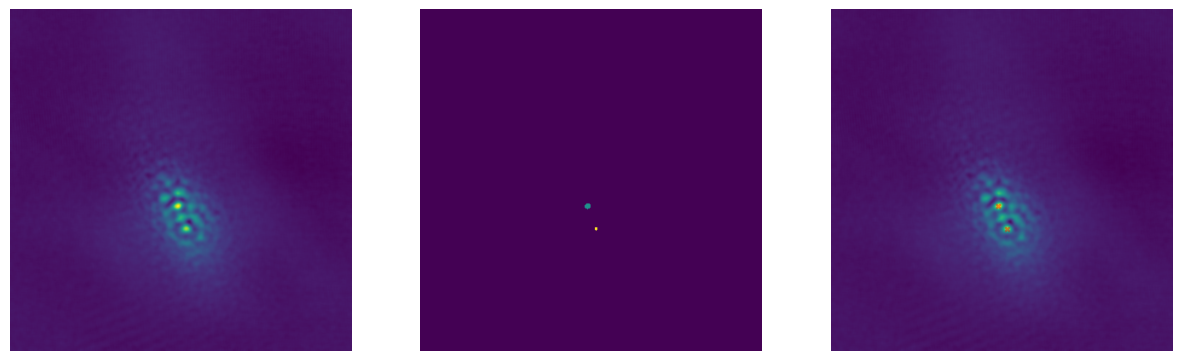

In [4]:
i, j = 10, 2
thresholds_droplets = [3000000, 2000000, 2500000, 2600000, 2700000, 2400000, 2300000, 2200000, 2300000, 2100000] # Y:/TwoDGas/2026/01/19/0046

close("all")
fig, axs = subplots(1, 3, figsize=(15, 5))

OD = ODs_dataset[i, j, :, :]

smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, thresholds_droplets[i])

axs[1].imshow(smooth_norm_OD)

axs[2].imshow(label_blobs)

axs[3].imshow(smooth_norm_OD)
axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.4)

for ax in axs
    ax.axis("off")
end

pygui(false);

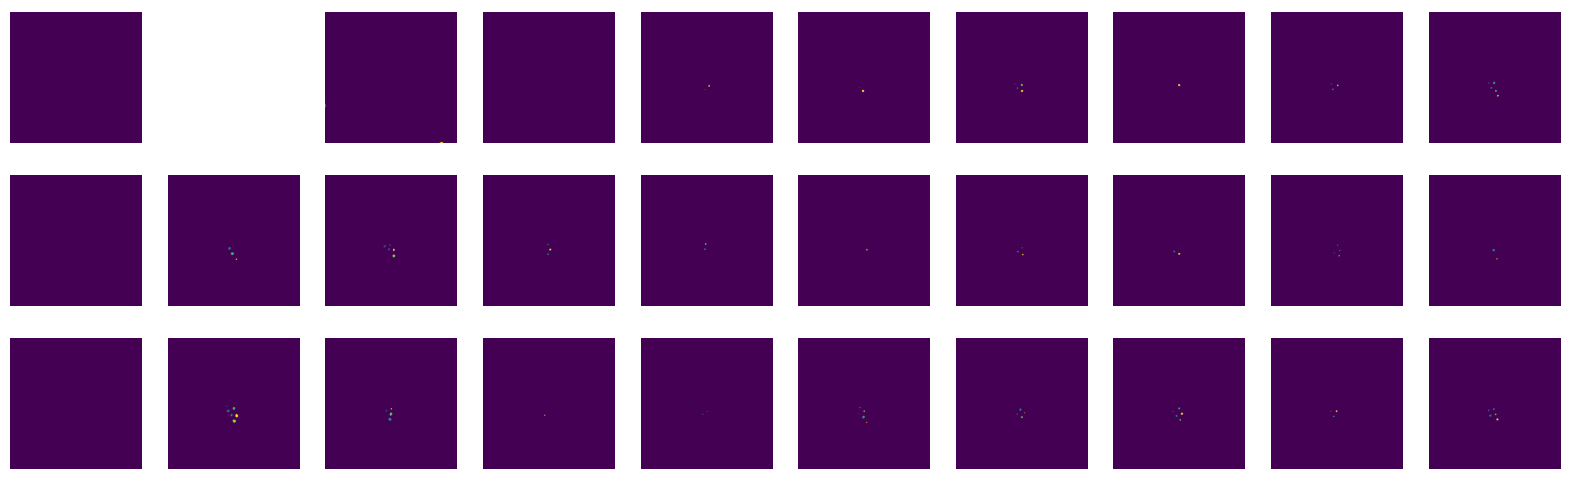

In [5]:
nbr_img_per_sat = 3

close("all")
fig, axs = subplots(nbr_img_per_sat, nbr_amp_laser, figsize=(2*nbr_amp_laser, 2*nbr_img_per_sat))

for i in 1:nbr_amp_laser
    for j = 1:nbr_img_per_sat
        OD = ODs_dataset[i, j, :, :]
        smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Smooth with flat kernel + normalize
        
        centers, label_blobs = find_droplets_radius_range(normalize(smooth_norm_OD), droplet_radius_range, thresholds_droplets[i])
        if length(centers) < 10 # Bigger than 10 = bad shot
            axs[j, i].imshow(label_blobs)
        end
        for ax in axs
            ax.axis("off")
        end
    end
end

# axis("off")
pygui(false);

# Find the droplets

In [6]:
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets")
end

"Images/2026_01_19_0046/Droplets"

In [7]:
nbr_droplets_ds = zeros(size(ODs_dataset)[1:2])
centers_droplets_ds = []
save_imgs = true

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for i in ProgressBar(1:nbr_amp_laser)
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets/$(unique(Amplitude_laser)[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets/$(unique(Amplitude_laser)[i])")
    end

    centers_droplets = []

    for j = 1:size(ODs_dataset)[2]
        OD = ODs_dataset[i, j, :, :]
        smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Smooth with flat kernel + normalize

        centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, thresholds_droplets[i])
        if length(centers) < 10
            if save_imgs
                axs[1].imshow(smooth_norm_OD)
                axs[2].imshow(label_blobs)
                axs[3].imshow(OD)
                axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.5)

                savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets/$(unique(Amplitude_laser)[i])/$(j-1).png")
                for ax in axs
                    ax.clear()
                end
            end

            nbr_droplets_ds[i, j] = length(centers)
            push!(centers_droplets, centers)
        else
            push!(centers_droplets, [])
        end
    end
    push!(centers_droplets_ds, centers_droplets)
end

close("all")

0.0%┣                                              ┫ 0/10 [00:01<00:-13, -1s/it]
10.0%┣████▏                                     ┫ 1/10 [00:03<Inf:Inf, InfGs/it]
20.0%┣█████████▍                                     ┫ 2/10 [00:04<00:36, 4s/it]
30.0%┣██████████████                                 ┫ 3/10 [00:06<00:21, 3s/it]
40.0%┣██████████████████▉                            ┫ 4/10 [00:08<00:15, 3s/it]
50.0%┣███████████████████████▌                       ┫ 5/10 [00:10<00:12, 2s/it]
60.0%┣████████████████████████████▏                  ┫ 6/10 [00:11<00:09, 2s/it]
70.0%┣█████████████████████████████████              ┫ 7/10 [00:13<00:06, 2s/it]
80.0%┣█████████████████████████████████████▋         ┫ 8/10 [00:14<00:04, 2s/it]
90.0%┣██████████████████████████████████████████▎    ┫ 9/10 [00:16<00:02, 2s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:17<00:00, 2s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:17<00:00, 2s/it]


In [8]:
@save "Saved_exp_data/Droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_droplets_ds nbr_droplets_ds